BASIC SCRIPT

In [1]:
!pip install deepchem           # DDEPCHEM
!pip install rdkit-pypi -qqq    # RDKIT
!pip install selfies            # SELFIES


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [1]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf

# Update TensorFlow to avoid deprecation warning
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


c:\Users\moham\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\moham\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


KeyboardInterrupt: 

In [3]:
ms = pd.read_pickle('/content/drive/MyDrive/DATASETS/NIST/_CHO1_NO_AROMATIC')
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz996,mz997,mz998,mz999,mz1000,Filter_Form,smiles,Arom,Filter,filter
14,"2-Pentanone, 3-ethyl-3-methyl-",C8H16O,128,19780-65-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC(C)(CC)C(C)=O,0,1,1
19,3-Methyl-3-hexen-2-ol,C7H14O,114,76966-27-3,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC=C(C)C(C)O,0,1,1
20,"Hexane, 1-(3-butenyloxy)-",C10H20O,156,107995-55-1,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCCCOCCC=C,0,1,1
31,"2-Hexanone, 3,3-dimethyl-",C8H16O,128,26118-38-7,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCC(C)(C)C(C)=O,0,1,1
33,"4-Methyl-1,6-heptadien-4-ol",C8H14O,126,25201-40-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CC(O)(CC=C)CC=C,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204501,"Furan, 2,5-dihydro-3-methyl-",C5H8O,84,1708-31-2,0,17,0,0,0,0,...,0,0,0,0,0,True,CC1=CCOC1,0,1,1
204508,"Butane, 1-(ethenyloxy)-",C6H12O,100,111-34-2,0,0,0,0,0,0,...,0,0,0,0,0,True,CCCCOC=C,0,1,1
204540,"3-Heptanone, 5-methyl-",C8H16O,128,541-85-5,0,0,0,0,0,0,...,0,0,0,0,0,True,CCC(C)CC(=O)CC,0,1,1
204547,Acetaldehyde,C2H4O,44,75-07-0,0,0,0,0,0,0,...,0,0,0,0,0,True,CC=O,0,1,1


In [4]:
# Create DEEPCHEM dataset
# First check if there are SMILES with a dot '.'
# These cannot be FEATURIZED and must be removed from the dataset.

X = ms.iloc[:,4:1004]     # spectra
y = ms.iloc[:,1005]       # smiles
se = []
dr = [] # all these compounds should be removed
c=0
for i in y:
  se.append(sf.encoder(i))  # contains all SELFIES
  if '.' in sf.encoder(i):  # check if there is a dot in the selfies
    dr.append(c)
  c=c+1
# remove compounds which will give an error when featurizing
a=0
for i in dr:
  ms = ms.drop([ms.index[i-a]])
  a=a+1
# create new DeepChem dataset
X = ms.iloc[:,4:1004]     # spectra
y = ms.iloc[:,1005]       # smiles
ds = dc.data.DiskDataset.from_numpy(X,y)
ds

<DiskDataset X.shape: (np.int64(6025), np.int64(1000)), y.shape: (np.int64(6025),), w.shape: (np.int64(6025),), task_names: [0]>

In [ ]:
# Make a dictionary of all 'SELFIES' parts in the dataset
dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/-Ring1]': 3,
 '[/C@@H1]': 4,
 '[/C]': 5,
 '[/O]': 6,
 '[=Branch1]': 7,
 '[=Branch2]': 8,
 '[=CH0]': 9,
 '[=CH1]': 10,
 '[=CH2]': 11,
 '[=C]': 12,
 '[=N]': 13,
 '[=O]': 14,
 '[Branch1]': 15,
 '[Branch2]': 16,
 '[C@@H1]': 17,
 '[C@@]': 18,
 '[C@H1]': 19,
 '[C@]': 20,
 '[CH0]': 21,
 '[CH1]': 22,
 '[CH2]': 23,
 '[C]': 24,
 '[N]': 25,
 '[O]': 26,
 '[P]': 27,
 '[Ring1]': 28,
 '[Ring2]': 29,
 '[S]': 30,
 '[\\-Ring1]': 31,
 '[\\C@@H1]': 32,
 '[\\C]': 33,
 '[nop]': 34}

In [ ]:
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
# RANDOM STRATIFIED SPLITTER: FOR VERY UMBALANCED DATA; IT DIVIDES THE POS AND NEG SAMPLES EVENLY
splitter = dc.splits.RandomStratifiedSplitter()
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1)

The model is a multi-task classifier capable of handling 3115 tasks simultaneously, each of which is a classification problem.
It takes 1000 input features and has two hidden layers of 3000 and 1000 units.
No dropout is applied, meaning the network is fully connected during training.

In [10]:
train_dataset

<NumpyDataset X.shape: (4761, 1000), y.shape: (4761, 3115), w.shape: (4761, 1), task_names: [   0    1    2 ... 3112 3113 3114]>

In [11]:
# MODEL: MultitaskClassifier
model = dc.models.MultitaskClassifier(n_tasks=3115, n_features=1000, layer_sizes=[1000, 1000, 1000], dropouts=0.1)

In [ ]:
model.fit(train_dataset, nb_epoch=50)

0.0017464572191238403

In [13]:
predictions = model.predict(test_dataset)

In [14]:
# Create a dictionairy (itos) to transfer the hot-encoding array into a array of SELFIES and SMILES
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos

{0: '[#Branch1]',
 1: '[#Branch2]',
 2: '[#C]',
 3: '[/-Ring1]',
 4: '[/C@@H1]',
 5: '[/C]',
 6: '[/O]',
 7: '[=Branch1]',
 8: '[=Branch2]',
 9: '[=CH0]',
 10: '[=CH1]',
 11: '[=CH2]',
 12: '[=C]',
 13: '[=N]',
 14: '[=O]',
 15: '[Branch1]',
 16: '[Branch2]',
 17: '[C@@H1]',
 18: '[C@@]',
 19: '[C@H1]',
 20: '[C@]',
 21: '[CH0]',
 22: '[CH1]',
 23: '[CH2]',
 24: '[C]',
 25: '[N]',
 26: '[O]',
 27: '[P]',
 28: '[Ring1]',
 29: '[Ring2]',
 30: '[S]',
 31: '[\\-Ring1]',
 32: '[\\C@@H1]',
 33: '[\\C]',
 34: '[nop]'}

In [15]:
test_dataset.get_shape()

((627, 1000), (627, 3115), (627, 1), (627,))

Molecule id                              = 250
Lenght of bit-string                     = 3115
Number of dictionary (SELFIES) items     = 35
Total lenghts of one-hot array           = 89
Predicted SELFIES:
---
PREDICTED SELFIES = [O][C][C][C][C][C][C][Branch1][Ring2][C][Ring1][=Branch1][C][Branch1][#Branch1][C][C][C][Ring1][#Branch1][=C][C][=C]
PREDICTED SMILES = OCC1CCC2C(C1)C(CCC2=C)C=C 


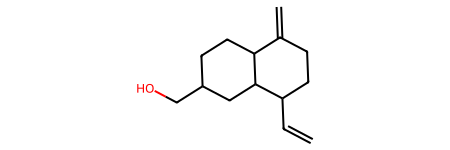

In [ ]:
# Molecule id (test_dataset)
id = 250
# PREDICTED MOLECULE
pred = []
for i in predictions[id]:
  if i[1] >= cutoff:
    pred.append(1)
  else:
    pred.append(0)

# THE PREDICTED SELFIES

sfc =''
a = len(pred) # e.g. 2664 its long array for 1 molecule because its one-flat encoded
b = len(itos) # e.g. lenght of the selfies database e.g. 37
c = int (a/b) # e.g. 2664/37 = 72
print (f'Molecule id                              = {id}')
print (f'Lenght of bit-string                     = {a}')
print (f'Number of dictionary (SELFIES) items     = {b}')
print (f'Total lenghts of one-hot array           = {int(a/b)}')
print (f'Predicted SELFIES:')
for i in range(c):
  for q in range(b):
    if pred[i*b+q]==1 and itos[q]!='[nop]':
      #print (itos[q])
      sfc = sfc + (itos[q])
print ('---')
sf_m = sf.decoder(sfc)

print (f'PREDICTED SELFIES = {sfc}')
print (f'PREDICTED SMILES = {sf_m} ')
Chem.MolFromSmiles(sf_m)

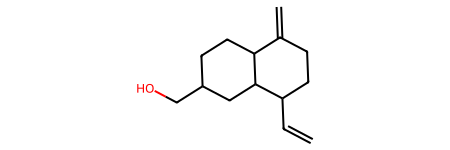

In [26]:
# THE REAL MOLECULE IN THE TEST_DATASET
compound_id = test_dataset.ids[id]
smile_id = ds.y[compound_id]
mol_id = Chem.MolFromSmiles(smile_id)
mol_id

In [27]:
a = Chem.RDKFingerprint(Chem.MolFromSmiles(sf_m))
b = Chem.RDKFingerprint(Chem.MolFromSmiles(smile_id))
c = DataStructs.FingerprintSimilarity(a,b, metric=DataStructs.DiceSimilarity)
print(f'Tanimoto similarity between predicted and real molecule = {c}')

Tanimoto similarity between predicted and real molecule = 1.0


In [ ]:
# Evaluation whole test set
# check if predicted smiles == real smiles
hit = 0
score=[]

for test_compound_id in range(len(test_dataset)):
  # create hot-encoding array of molecule id
  pred = []
  for i in predictions[test_compound_id]:
    if i[1] >= cutoff:
      pred.append(1)
    else:
      pred.append(0)

  sfc =''
  a = len(pred)
  b = len(itos)
  c = int (a/b)

  for i in range(c):
    for q in range(b):
      if pred[i*b+q]==1 and itos[q]!='[nop]':
        # print (itos[q])
        sfc = sfc + (itos[q])
  sf_m = sf.decoder(sfc)

  # real molecule
  compound_id = test_dataset.ids[test_compound_id]
  smile_id = ds.y[compound_id]

  # Tanimoto similarity
  a = Chem.RDKFingerprint(Chem.MolFromSmiles(sf_m))
  b = Chem.RDKFingerprint(Chem.MolFromSmiles(smile_id))
  score.append(DataStructs.FingerprintSimilarity(a,b, metric=DataStructs.DiceSimilarity))
  print (test_compound_id,'-------', sf_m, '--------', smile_id, DataStructs.FingerprintSimilarity(a,b, metric=DataStructs.DiceSimilarity))
  if sf_m == smile_id:
    hit = hit + 1

score = np.array(score)
sum_score_1 = sum(score>=1)
sum_score_09 = sum(score>=0.9)
sum_score_06 = sum(score>=0.6)

print (f'Correct smiles predictions: {hit} (={int(hit/len(test_dataset.X)*100)}%). Test set contains in total {len(test_dataset.X)} compounds.')
print (f'Tanimoto similarity == 1.0: {sum_score_1} (={int(sum_score_1/len(test_dataset.X)*100)}%). Test set contains in total {len(test_dataset.X)} compounds.')
print (f'Tanimoto similarity >= 0.9: {sum_score_09} (={int(sum_score_09/len(test_dataset.X)*100)}%). Test set contains in total {len(test_dataset.X)} compounds.')
print (f'Tanimoto similarity >= 0.6: {sum_score_06} (={int(sum_score_06/len(test_dataset.X)*100)}%). Test set contains in total {len(test_dataset.X)} compounds.')

0 ------- CCC=C(C)C(C)O -------- CCC=C(C)C(C)O 1.0
1 ------- CCCCCCCOCCC=C -------- CCCCCCOCCC=C 0.9649122807017544
2 ------- CC(=O)C1CC2C(C)=C1CC2(C)C -------- CC(=O)C1CC2C(C=C1C)C2(C)C 0.7927382753403933
3 ------- CC(C)[CH1]=[CH0]=[CH0](C1CCCC1)C(C)=O -------- CC(C)[CH]=[C]=[C](C1CCCC1)C(C)=O 1.0
4 ------- CCC(C=C)CCC(C)=O -------- CCC(CC)=CCCC(C)=O 0.4050632911392405
5 ------- C=COC=C -------- C=COC=C 1.0
6 ------- CCCCCC(=O)C(C)C -------- CCCCCC(=O)C(C)C 1.0
7 ------- CCC(CC)C(O)C#C -------- CCC(CC)C(O)C#C 1.0
8 ------- CCCC(=O)CCC(CC)CC -------- CCCC(=O)CCC(CC)CC 1.0
9 ------- CC(C)CCC(=O)C(C)CC -------- CC(C)CCC(=O)C(C)C 0.912
10 ------- CC(C)C(C)C(C)=O -------- CC(C)C(C)C(C)=O 1.0
11 ------- CC1(C)OCCC2CCCC1C2 -------- CC1(C)OCC2CCCCC12 0.8775510204081632
12 ------- CCCCCCOCCCCCCCCC -------- CCCCCCOCCC(C)CCC 0.7567567567567568
13 ------- CCCCCC(=O)C(C)CC -------- CCCCCC(=O)C(C)CC 1.0
14 ------- CC(C)=O -------- CC(C)=O 1.0
15 ------- CCC(C)CC(C)=O -------- CCC(C)CC(C)=O 1.0
16 -